<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 700; line-height: 1.2;">
        Fusión de Datos (Merge, Join, Concat)
      </h1>
      <p style="margin: 6px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Programación para Ciencia de Datos
      </p>
    </td>
    <td style="vertical-align: middle; text-align: right; border: none; padding: 15px 20px; min-width: 240px; font-family: system-ui, -apple-system, sans-serif;">
      <div style="font-size: 0.9em; color: #334155; line-height: 1.5;">
        <strong style="color: #1e3a8a; font-size: 1em;">Especialización en Ciencia de Datos</strong><br>
        <span style="color: #475569; font-weight: 600;">USTA Tunja</span><br><br>
        <b>Santiago A. Zúñiga M.</b><br>
        ✉️ <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
      </div>
    </td>
  </tr>
</table>

---
## Fusión de Datos 

En Pandas, `merge`, `join` y `concat` son tres métodos diferentes que se utilizan para combinar datos de múltiples tablas, pero tienen casos de uso y comportamientos distintos. En resumen:

- **Merge**: Úsalo cuando desees realizar una operación compleja, como combinar DataFrames basándote en columnas o índices comunes (muy similar a los JOINs de SQL).
- **Join**: Úsalo cuando quieras combinar DataFrames basándote directamente en sus **índices**.
- **Concat**: Úsalo cuando quieras pegar o concatenar DataFrames apilándolos a lo largo de un eje específico (uno encima del otro, o uno al lado del otro).


### Importando Nuevos Datos
Para explorar esto, dejaremos los vinos un momento y utilizaremos dos conjuntos de datos climáticos de la [NOAA](https://www.ncdc.noaa.gov/cdo-web/).

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
import pandas as pd

climate_temp = pd.read_csv("data/climate_temp.csv")
print("Shape Temp:", climate_temp.shape)
display(climate_temp.head())

climate_precip = pd.read_csv("data/climate_precip.csv")
print("Shape Precip:", climate_precip.shape)
display(climate_precip.head())

Shape Temp: (127020, 21)


,STATION,STATION_NAME,ELEVATION,LATITUDE,LONGITUDE,DATE,DLY-CLDD-BASE45,DLY-CLDD-BASE50,DLY-CLDD-BASE55,DLY-CLDD-BASE57,...,DLY-CLDD-NORMAL,DLY-CLDD-BASE70,DLY-CLDD-BASE72,DLY-HTDD-BASE40,DLY-HTDD-BASE45,DLY-HTDD-BASE50,DLY-HTDD-BASE55,DLY-HTDD-BASE57,DLY-HTDD-BASE60,DLY-HTDD-NORMAL
0,GHCND:USC00049099,TWENTYNINE PALMS CA US,602,34.12806,-116.03694,20100101,6,2,-7777,-7777,...,0,0,0,-7777,1,2,6,7,10,15
1,GHCND:USC00049099,TWENTYNINE PALMS CA US,602,34.12806,-116.03694,20100102,6,2,1,-7777,...,0,0,0,-7777,1,2,6,7,10,15
2,GHCND:USC00049099,TWENTYNINE PALMS CA US,602,34.12806,-116.03694,20100103,6,2,1,-7777,...,0,0,0,-7777,1,2,5,7,10,15
3,GHCND:USC00049099,TWENTYNINE PALMS CA US,602,34.12806,-116.03694,20100104,6,2,1,-7777,...,0,0,0,-7777,1,2,5,7,10,15
4,GHCND:USC00049099,TWENTYNINE PALMS CA US,602,34.12806,-116.03694,20100105,6,2,1,-7777,...,0,0,0,-7777,-7777,2,5,7,10,15


Shape Precip: (151110, 29)


,STATION,STATION_NAME,DATE,DLY-PRCP-25PCTL,DLY-SNWD-25PCTL,DLY-SNOW-25PCTL,DLY-PRCP-50PCTL,DLY-SNWD-50PCTL,DLY-SNOW-50PCTL,DLY-PRCP-75PCTL,...,DLY-PRCP-PCTALL-GE100HI,DLY-SNWD-PCTALL-GE001WI,DLY-SNWD-PCTALL-GE010WI,DLY-SNWD-PCTALL-GE003WI,DLY-SNWD-PCTALL-GE005WI,DLY-SNOW-PCTALL-GE001TI,DLY-SNOW-PCTALL-GE010TI,DLY-SNOW-PCTALL-GE100TI,DLY-SNOW-PCTALL-GE030TI,DLY-SNOW-PCTALL-GE050TI
0,GHCND:USC00049099,TWENTYNINE PALMS CA US,20100101,-6.66,-666,-66.6,-6.66,-666,-66.6,-6.66,...,3,-9999,0,-9999,-9999,-9999,-9999,0,-9999,-9999
1,GHCND:USC00049099,TWENTYNINE PALMS CA US,20100102,-6.66,-666,-66.6,-6.66,-666,-66.6,-6.66,...,3,-9999,0,-9999,-9999,-9999,-9999,0,-9999,-9999
2,GHCND:USC00049099,TWENTYNINE PALMS CA US,20100103,-6.66,-666,-66.6,-6.66,-666,-66.6,-6.66,...,3,-9999,0,-9999,-9999,-9999,-9999,0,-9999,-9999
3,GHCND:USC00049099,TWENTYNINE PALMS CA US,20100104,-6.66,-9999,-9999.0,-6.66,-9999,-9999.0,-6.66,...,3,0,0,0,0,0,0,0,0,0
4,GHCND:USC00049099,TWENTYNINE PALMS CA US,20100105,-6.66,-9999,-9999.0,-6.66,-9999,-9999.0,-6.66,...,3,0,0,0,0,0,0,0,0,0


---
### 1. Merge (Fusión por Columnas Comunes)

`merge()` te permite especificar las columnas clave por las cuales se debe realizar la fusión, al igual que los joins de SQL (`inner`, `outer`, `left`, `right`).

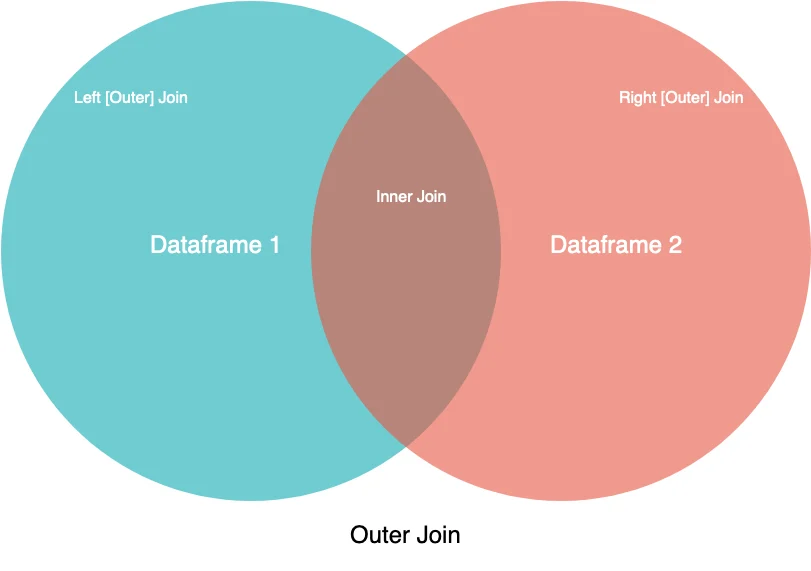

In [2]:
# Aislaremos las precipitaciones de UNA SOLA estación para ver más claros los ejemplos
precip_one_station = climate_precip.query("STATION == 'GHCND:USC00045721'")
precip_one_station.shape

(365, 29)

#### Inner Join (Por defecto)
Fusión estricta: solo mantiene las filas que **existen y coinciden en AMBOS** DataFrames.

In [3]:
# Si no especificas 'how' ni 'on', pandas busca columnas con el mismo nombre y hace un inner join
inner_merged = pd.merge(precip_one_station, climate_temp)
display(inner_merged.head())
print("Shape del inner_merged:", inner_merged.shape)

,STATION,STATION_NAME,DATE,DLY-PRCP-25PCTL,DLY-SNWD-25PCTL,DLY-SNOW-25PCTL,DLY-PRCP-50PCTL,DLY-SNWD-50PCTL,DLY-SNOW-50PCTL,DLY-PRCP-75PCTL,...,DLY-CLDD-NORMAL,DLY-CLDD-BASE70,DLY-CLDD-BASE72,DLY-HTDD-BASE40,DLY-HTDD-BASE45,DLY-HTDD-BASE50,DLY-HTDD-BASE55,DLY-HTDD-BASE57,DLY-HTDD-BASE60,DLY-HTDD-NORMAL
0,GHCND:USC00045721,MITCHELL CAVERNS CA US,20100101,0.04,-666,-66.6,0.16,-666,-66.6,0.44,...,0,0,0,1,3,6,10,12,14,19
1,GHCND:USC00045721,MITCHELL CAVERNS CA US,20100102,0.05,-666,-66.6,0.16,-666,-66.6,0.44,...,0,0,0,1,3,6,10,11,14,19
2,GHCND:USC00045721,MITCHELL CAVERNS CA US,20100103,0.05,-666,-66.6,0.16,-666,-66.6,0.45,...,0,0,0,1,2,5,9,11,14,19
3,GHCND:USC00045721,MITCHELL CAVERNS CA US,20100104,0.05,-666,-66.6,0.16,-666,-66.6,0.45,...,0,0,0,1,2,5,9,11,14,19
4,GHCND:USC00045721,MITCHELL CAVERNS CA US,20100105,0.05,-666,-66.6,0.17,-666,-66.6,0.46,...,0,0,0,1,2,5,9,11,14,19


Shape del inner_merged: (365, 47)


Obtienes 365 filas porque cualquier fila del dataset grande de temperaturas que no coincidió con nuestra pequeña estación de 365 días fue descartada.

¿Qué pasa si quieres fusionar los dos conjuntos de datos completos, especificando explícitamente en qué columnas deben buscar coincidencias? Usas el parámetro `on`:

In [4]:
inner_merged_total = pd.merge(
    climate_temp, 
    climate_precip, 
    on=["STATION", "DATE"] # Lista de columnas clave a cruzar
)
print("Shape total:", inner_merged_total.shape)

Shape total: (123005, 48)


#### Outer Join
Fusión inclusiva: mantiene TODAS las filas de ambos DataFrames. Si no hay coincidencia, rellena los huecos con `NaN`.

In [5]:
outer_merged = pd.merge(
    precip_one_station, 
    climate_temp, 
    how="outer", 
    on=["STATION", "DATE"]
)
print("Shape outer_merged:", outer_merged.shape)

Shape outer_merged: (127020, 48)


Con un `outer join`, puedes esperar tener la misma cantidad de filas que el DataFrame más grande (127020), ya que no se pierde ninguna.

#### Left y Right Join
Mantienen **todas** las filas de la tabla de la izquierda (el primer argumento) o de la derecha (el segundo argumento), respectivamente. Los faltantes se rellenan con `NaN`.

In [6]:
# Left Join (Mantiene todas las filas de climate_temp)
left_merged = pd.merge(climate_temp, precip_one_station, how="left", on=["STATION", "DATE"])
print("Shape left_merged:", left_merged.shape)

# Right Join (Mantiene todas las filas de climate_temp, que es el de la derecha ahora)
right_merged = pd.merge(precip_one_station, climate_temp, how="right", on=["STATION", "DATE"])
print("Shape right_merged:", right_merged.shape)

Shape left_merged: (127020, 48)
Shape right_merged: (127020, 48)


---
##### 🛠️ Práctica 1: Merge
Haz un `inner join` entre `precip_one_station` y `climate_temp`, pero esta vez cruza los datos **SOLO por la columna `"DATE"`**.
Imprime el `.shape` del resultado. ¿Notaste cómo la cantidad de filas se dispara al no cruzar también por la estación?

In [7]:
# Escribe tu código aquí



<details>
<summary><b>💡 Haz clic aquí para ver la solución</b></summary>

```python
merge_date_only = pd.merge(precip_one_station, climate_temp, on=["DATE"], how="inner")
print("Shape:", merge_date_only.shape)
```
</details>


---
### 2. Join (Fusión por Índices)

`join()` utiliza `merge()` por debajo, pero proporciona una interfaz mucho más simplificada y, por defecto, combina los DataFrames basándose en sus **Índices** en lugar de sus columnas.

Para manejar los nombres de columnas superpuestos, usamos `lsuffix` (sufijo izquierdo) y `rsuffix` (sufijo derecho).

In [8]:
joined_df = precip_one_station.join(climate_temp, lsuffix="_left", rsuffix="_right")
display(joined_df.head())
print("Shape:", joined_df.shape)

,STATION_left,STATION_NAME_left,DATE_left,DLY-PRCP-25PCTL,DLY-SNWD-25PCTL,DLY-SNOW-25PCTL,DLY-PRCP-50PCTL,DLY-SNWD-50PCTL,DLY-SNOW-50PCTL,DLY-PRCP-75PCTL,...,DLY-CLDD-NORMAL,DLY-CLDD-BASE70,DLY-CLDD-BASE72,DLY-HTDD-BASE40,DLY-HTDD-BASE45,DLY-HTDD-BASE50,DLY-HTDD-BASE55,DLY-HTDD-BASE57,DLY-HTDD-BASE60,DLY-HTDD-NORMAL
1460,GHCND:USC00045721,MITCHELL CAVERNS CA US,20100101,0.04,-666,-66.6,0.16,-666,-66.6,0.44,...,0,0,0,1,3,6,10,12,14,19
1461,GHCND:USC00045721,MITCHELL CAVERNS CA US,20100102,0.05,-666,-66.6,0.16,-666,-66.6,0.44,...,0,0,0,1,3,6,10,11,14,19
1462,GHCND:USC00045721,MITCHELL CAVERNS CA US,20100103,0.05,-666,-66.6,0.16,-666,-66.6,0.45,...,0,0,0,1,2,5,9,11,14,19
1463,GHCND:USC00045721,MITCHELL CAVERNS CA US,20100104,0.05,-666,-66.6,0.16,-666,-66.6,0.45,...,0,0,0,1,2,5,9,11,14,19
1464,GHCND:USC00045721,MITCHELL CAVERNS CA US,20100105,0.05,-666,-66.6,0.17,-666,-66.6,0.46,...,0,0,0,1,2,5,9,11,14,19


Shape: (365, 50)


Si de verdad necesitas usar `join()` comparando por el valor de columnas (como STATION y DATE), primero debes convertir esas columnas en los índices temporales del DataFrame usando `.set_index()`:

In [9]:
inner_joined_total = climate_temp.join(
    climate_precip.set_index(["STATION", "DATE"]), 
    on=["STATION", "DATE"], 
    how="inner", 
    lsuffix="_x", 
    rsuffix="_y"
)
print("Shape inner joined:", inner_joined_total.shape)

Shape inner joined: (123005, 48)


---
##### 🛠️ Práctica 2: Join
Para no complicarnos con el dataset de clima, utilicemos dos DataFrames de juguete que ya tienen la columna `id` configurada como índice.

In [10]:
df_a = pd.DataFrame({'id': [1, 2, 3], 'nombre': ['Ana', 'Beto', 'Cata']}).set_index('id')
df_b = pd.DataFrame({'id': [1, 2, 4], 'edad': [25, 30, 22]}).set_index('id')
display(df_a, df_b)


,nombre
id,
1,Ana
2,Beto
3,Cata


,edad
id,
1,25
2,30
4,22


Aplica un `.join()` directo de `df_a` con `df_b` e imprime el resultado. Nota cómo al ser un Left Join por defecto, el id '3' se queda, pero el id '4' se descarta.

In [11]:
# Escribe tu código aquí



<details>
<summary><b>💡 Haz clic aquí para ver la solución</b></summary>

```python
resultado_join = df_a.join(df_b)
display(resultado_join)
```
</details>


---
### 3. Concat (Apilado de Datos)

`concat` no realiza fusiones buscando coincidencias de valores como tal; simplemente agarra los DataFrames y los **apila** o **pega** a lo largo de un eje (filas o columnas).

#### Concatenación Vertical (Por Filas - Axis 0)

In [12]:
# Apilamos el DataFrame de 365 filas consigo mismo (uno encima del otro)
double_precip = pd.concat([precip_one_station, precip_one_station])
print("Shape duplicado:", double_precip.shape)

# ⚠️ Los índices se duplican. Para forzar un índice limpio del 0 en adelante usamos ignore_index
reindexed = pd.concat([precip_one_station, precip_one_station], ignore_index=True)
display(reindexed.head())

Shape duplicado: (730, 29)


,STATION,STATION_NAME,DATE,DLY-PRCP-25PCTL,DLY-SNWD-25PCTL,DLY-SNOW-25PCTL,DLY-PRCP-50PCTL,DLY-SNWD-50PCTL,DLY-SNOW-50PCTL,DLY-PRCP-75PCTL,...,DLY-PRCP-PCTALL-GE100HI,DLY-SNWD-PCTALL-GE001WI,DLY-SNWD-PCTALL-GE010WI,DLY-SNWD-PCTALL-GE003WI,DLY-SNWD-PCTALL-GE005WI,DLY-SNOW-PCTALL-GE001TI,DLY-SNOW-PCTALL-GE010TI,DLY-SNOW-PCTALL-GE100TI,DLY-SNOW-PCTALL-GE030TI,DLY-SNOW-PCTALL-GE050TI
0,GHCND:USC00045721,MITCHELL CAVERNS CA US,20100101,0.04,-666,-66.6,0.16,-666,-66.6,0.44,...,11,4,0,3,3,9,6,0,-9999,-9999
1,GHCND:USC00045721,MITCHELL CAVERNS CA US,20100102,0.05,-666,-66.6,0.16,-666,-66.6,0.44,...,11,4,0,3,3,10,6,0,-9999,-9999
2,GHCND:USC00045721,MITCHELL CAVERNS CA US,20100103,0.05,-666,-66.6,0.16,-666,-66.6,0.45,...,11,4,0,3,3,10,6,0,-9999,-9999
3,GHCND:USC00045721,MITCHELL CAVERNS CA US,20100104,0.05,-666,-66.6,0.16,-666,-66.6,0.45,...,11,4,0,3,2,10,6,0,-9999,-9999
4,GHCND:USC00045721,MITCHELL CAVERNS CA US,20100105,0.05,-666,-66.6,0.17,-666,-66.6,0.46,...,11,4,0,3,2,10,6,0,-9999,-9999


Si apilamos verticalmente dos DataFrames que **tienen columnas diferentes**, Pandas conservará todas las columnas (comportamiento Outer) y rellenará con `NaN` los vacíos:

In [13]:
outer_joined = pd.concat([climate_precip, climate_temp])
print("Shape:", outer_joined.shape)

Shape: (278130, 47)


Podemos forzarlo a que, al apilar verticalmente, **solo conserve las columnas que ambos tienen en común** (`join="inner"`):

In [14]:
inner_joined = pd.concat([climate_temp, climate_precip], join="inner")
display(inner_joined.head())

,STATION,STATION_NAME,DATE
0,GHCND:USC00049099,TWENTYNINE PALMS CA US,20100101
1,GHCND:USC00049099,TWENTYNINE PALMS CA US,20100102
2,GHCND:USC00049099,TWENTYNINE PALMS CA US,20100103
3,GHCND:USC00049099,TWENTYNINE PALMS CA US,20100104
4,GHCND:USC00049099,TWENTYNINE PALMS CA US,20100105


#### Concatenación Horizontal (Por Columnas - Axis 1)
Pega los DataFrames de lado a lado en lugar de uno encima de otro.

In [15]:
inner_joined_cols = pd.concat([climate_temp, climate_precip], axis="columns", join="inner")
print("Shape concatenación de columnas:", inner_joined_cols.shape)

Shape concatenación de columnas: (127020, 50)


---
##### 🛠️ Práctica 3: Concat
Utiliza la función `pd.concat` para apilar verticalmente el DataFrame `df_a` (de la práctica anterior) consigo mismo. 
Asegúrate de pasar el parámetro necesario para **resetear el índice** y que cuente de forma continua en vez de repetir el 1, 2, 3.

In [16]:
# Escribe tu código aquí



<details>
<summary><b>💡 Haz clic aquí para ver la solución</b></summary>

```python
resultado_concat = pd.concat([df_a, df_a], ignore_index=True)
display(resultado_concat)
```
</details>
